# Support vector machines

## Maximum-margin classification

A support vector machine (SVM) is a classifier that searches for the *decision boundary that separates the classes by the largest possible margin*. For linearly separable data with labels $y_i \in \{-1, +1\}$, the boundary is the hyperplane $\boldsymbol{w}^\top \boldsymbol{x} + b = 0$ that maximizes the margin while still classifying every training point correctly,

$$
\min_{\boldsymbol{w}, b} \ \tfrac{1}{2}\lVert \boldsymbol{w} \rVert^2
\quad \text{subject to} \quad
y_i \left( \boldsymbol{w}^\top \boldsymbol{x}_i + b \right) \ge 1 \ \ \forall i
$$

(1)

Only the training points closest to the boundary — the *support vectors* — determine its position; all other points could be removed without changing the solution.

Real data is rarely perfectly separable, so a *soft-margin* version introduces slack variables, controlled by a regularization parameter $C$: a small $C$ allows more margin violations (a smoother boundary, less overfitting), while a large $C$ penalizes violations heavily (a tighter fit to the training data).

## The kernel trick

Many data sets are not linearly separable in their original feature space. The *kernel trick* implicitly maps the data into a higher-dimensional space where a linear separation becomes possible, without ever computing the mapping $\phi(\boldsymbol{x})$ explicitly — only the kernel (inner product in the new space) is needed,

$$
k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \phi(\boldsymbol{x}_i)^\top \phi(\boldsymbol{x}_j)
$$

(2)

A common nonlinear choice is again the RBF kernel of Eq. (1) in the GPR notebook, $k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \exp(-\gamma \lVert \boldsymbol{x}_i - \boldsymbol{x}_j \rVert^2)$, where $\gamma$ controls how far the influence of a single training example reaches.

## Library imports

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use the **breast cancer** data set: 569 samples, 30 numerical features from digitized FNA biopsy images, and a binary diagnosis (malignant/benign). All 30 features are standardized, since the SVM's margin, Eq. (1), and the RBF kernel, Eq. (2), both depend on Euclidean distances and are sensitive to feature scale.

In [34]:
cancer = sklearn.datasets.load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0,
)

scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model definition

We fit an SVM with an RBF kernel, Eq. (2), using all 30 features. The regularization parameter `C` and the kernel width `gamma` are the two main hyperparameters to tune.

In [35]:
svm = sklearn.svm.SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
)


## Model training

In [36]:
svm.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Decision boundary

With 30 features we can not plot the decision boundary directly, so in order to visualize *how* the RBF kernel separates the two diagnoses, we project the (scaled) training data onto its first two principal components (see PCA notebook) and project the 2D mesh into the 30D feature space, where it is correctly evaluated by the SVM.

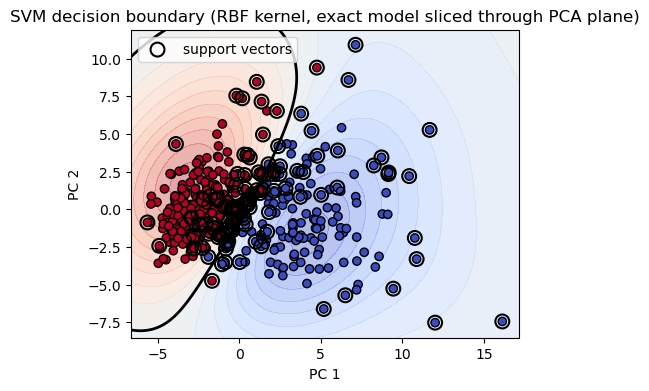

In [37]:
pca = sklearn.decomposition.PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train_scaled)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)

# map the 2D grid back into the original 30D (scaled) feature space,
# then evaluate the ACTUAL trained SVM there
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_high_d = pca.inverse_transform(grid_2d)
Z = svm.decision_function(grid_high_d).reshape(xx.shape)

# project the real support vectors into the same 2D view for reference
support_vectors_2d = pca.transform(svm.support_vectors_)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, levels=20, cmap=plt.cm.coolwarm, alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], colors="k", linewidths=2)
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor="k")
plt.scatter(
    support_vectors_2d[:, 0], support_vectors_2d[:, 1],
    facecolors="none", edgecolors="black", s=100, linewidths=1.5, label="support vectors",
)
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.legend()
plt.title("SVM decision boundary (RBF kernel, exact model sliced through PCA plane)")
plt.show()

Note that the support vectors are not exactly located on the decision boundaries, which is due to loss of information during the pca projection from 30D into 2D.

## Model evaluation

In [38]:
y_pred = svm.predict(X_test_scaled)

print(sklearn.metrics.classification_report(y_test, y_pred, target_names=cancer.target_names))


              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



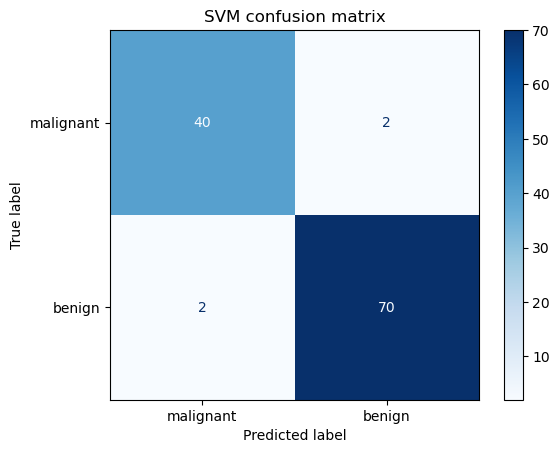

In [39]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("SVM confusion matrix")
plt.show()


Comparing the amount of parameters to the NN basic example shows how few parameters are actually fitted for the SVM, namely simply the amount of hyperplanes dividing the different possible classes (in this case only 1) times the amount of input features (in this case 30) and adding a single final bias coefficient. This is a lot less than the (already very light weight) NN example with 401 parameters.

In [40]:
print(
    f"The amount of coefficients used by the SVM model are "
    f"{np.prod(svm._get_coef().shape) + len(svm.intercept_)}"
)

The amount of coefficients used by the SVM model are 31


## Take-away

SVMs are a strong choice with limited resources: they tend to work well even with relatively few training samples and many features, are convex (a single global optimum, no random initialization issues), and the kernel trick gives flexible, nonlinear decision boundaries without manual feature engineering. The main practical cost is that training scales poorly to very large data sets (typically beyond tens of thousands of samples for the kernelized version).